# First steps with the new code
Lets try the new Trefftzmesh

In [1]:
from trefftz.mesh import TrefftzMesh

In [2]:
from enum import IntEnum, StrEnum



class WaveguideRegionsGMSH(IntEnum):
    OMEGA = 0
    GAMMA = 1
    SIGMA_L = 2
    SIGMA_R = 3


def CleanWaveguide_GMSH(H: float = 1., R: float = 5., lc: float = 0.3, verbose: bool = False) -> TrefftzMesh[WaveguideRegionsGMSH]:
    '''Creates a domain corresponging to a waveguide without scatterers.
    It assumes the default tags for the subregions, i.e.:
    - Omega = 0
    - Gamma = 1
    - Sigma = 2
    '''
    import gmsh


    gmsh.initialize()
    gmsh.option.setNumber("General.Terminal", int(verbose))
    gmsh.model.add("Waveguide")
    p0 = gmsh.model.geo.addPoint(-R, 0., 0., lc)
    p1 = gmsh.model.geo.addPoint( R, 0., 0., lc)
    p2 = gmsh.model.geo.addPoint( R,  H, 0., lc)
    p3 = gmsh.model.geo.addPoint(-R,  H, 0., lc)

    bottom = gmsh.model.geo.addLine(p0, p1)
    right  = gmsh.model.geo.addLine(p1, p2)
    top    = gmsh.model.geo.addLine(p2, p3)
    left   = gmsh.model.geo.addLine(p3, p0)

    boundary = gmsh.model.geo.addCurveLoop([bottom, right, top, left])
    domain = gmsh.model.geo.addPlaneSurface([boundary])
    gmsh.model.geo.synchronize()

    gmsh.model.addPhysicalGroup(2, [domain], WaveguideRegionsGMSH.OMEGA, "Omega")
    gmsh.model.addPhysicalGroup(1, [bottom, top], WaveguideRegionsGMSH.GAMMA, "Gamma")
    gmsh.model.addPhysicalGroup(1, [left], WaveguideRegionsGMSH.SIGMA_L, "Sigma_L")
    gmsh.model.addPhysicalGroup(1, [right], WaveguideRegionsGMSH.SIGMA_R, "Sigma_R")
    
    gmsh.model.geo.synchronize()
    gmsh.model.mesh.generate(2)
 
    mesh = TrefftzMesh.from_gmsh(gmsh.model, boundary_regions = WaveguideRegionsGMSH) #gmsh needs to be initialized for this to work
    
    gmsh.finalize()

    return mesh


class WaveguideRegionsNGSOLVE(StrEnum):
    OMEGA = "Omega"
    GAMMA = "Gamma"
    SIGMA_L = "Sigma_L"
    SIGMA_R = "Sigma_R"

def CleanWaveguide_NGSOLVE(H: float = 1., R: float = 5., lc: float = 0.3, verbosity: int = 0) -> TrefftzMesh[WaveguideRegionsNGSOLVE]:

    '''Creates a domain corresponging to a waveguide without scatterers.
    It assumes the default tags for the subregions, i.e.:
    - Omega = 0
    - Gamma = 1
    - Sigma = 2
    '''
    from netgen.geom2d import SplineGeometry
    from ngsolve import Mesh
    geo = SplineGeometry()
    p0 = geo.AddPoint(-R, 0.)
    p1 = geo.AddPoint( R, 0.)
    p2 = geo.AddPoint( R, H)
    p3 = geo.AddPoint(-R, H)
 
    bottom = geo.Append(["line", p0, p1], bc=WaveguideRegionsNGSOLVE.GAMMA)
    right  = geo.Append(["line", p1, p2], bc=WaveguideRegionsNGSOLVE.SIGMA_R)
    top    = geo.Append(["line", p2, p3], bc=WaveguideRegionsNGSOLVE.GAMMA)
    left   = geo.Append(["line", p3, p0], bc=WaveguideRegionsNGSOLVE.SIGMA_L)


    ngmesh = Mesh(geo.GenerateMesh(maxh=lc, perfstepsend=verbosity))

    
    mesh = TrefftzMesh.from_ngsolve(ngmesh, boundary_regions=WaveguideRegionsNGSOLVE)

    return mesh



In [36]:
R = 1.
H = 1. 

NGSOLVE = False

lc = 0.2

if NGSOLVE:
    mesh = CleanWaveguide_NGSOLVE(R=R, H=H, verbosity=0, lc=lc)
    WaveguideRegions = WaveguideRegionsNGSOLVE
else:
    mesh = CleanWaveguide_GMSH(R=R, H=H, verbose=True, lc=lc)
    WaveguideRegions = WaveguideRegionsGMSH


Info    : Meshing 1D...
Info    : [  0%] Meshing curve 1 (Line)
Info    : [ 30%] Meshing curve 2 (Line)
Info    : [ 60%] Meshing curve 3 (Line)
Info    : [ 80%] Meshing curve 4 (Line)
Info    : Done meshing 1D (Wall 0.000226841s, CPU 0.000353s)
Info    : Meshing 2D...
Info    : Meshing surface 1 (Plane, Frontal-Delaunay)
Info    : Done meshing 2D (Wall 0.00114524s, CPU 0.001231s)
Info    : 80 nodes 162 elements


In [37]:
# from trefftz.mesh.checking_utilities import explore_edges
# import matplotlib
# matplotlib.use("TkAgg")
# print(matplotlib.get_backend())

In [38]:
# import matplotlib.pyplot as plt
# fig, ax = plt.subplots()

In [39]:
# explore_edges(mesh,figax=(fig, ax))

In [40]:
from problems.base2 import Problem

In [78]:
from trefftz.dg.basis import LinearlySpacedBasis

k = 8.0

basis = LinearlySpacedBasis(N_elements=mesh.n_triangles, k=k, N_theta=15)

In [79]:
from problems.base2 import SoundHardBC, NtDBC

In [80]:
boundary_conditions = {WaveguideRegions.GAMMA: SoundHardBC(),
                       WaveguideRegions.SIGMA_L: NtDBC(truncating_radius=R, data=1.),
                       WaveguideRegions.SIGMA_R: NtDBC(truncating_radius=R, data=1.)}

In [81]:
from problems.base2 import SerialNumerics

In [82]:
from trefftz.dg.serial_kernels import SoundHardKernel, UltraWeakKernel, NtDLocal, WaveguideNtD_nonlocal

In [83]:
serial_numerics = SerialNumerics(interior_kernel=UltraWeakKernel(a=0.5, b=0.5),
                                 local_boundary_kernels={SoundHardBC: SoundHardKernel(d_1 = 0.5),
                                                         NtDBC: NtDLocal(R=R, d_2=0.5, H=H, n=0)},
                                 nonlocal_boundary_kernels={NtDBC: WaveguideNtD_nonlocal(R=R, d_2=0.5, M = 20, H = 1.)})

In [84]:
P = Problem(mesh=mesh, wavenumber=k, basis=basis, boundary_conditions=boundary_conditions, numerics=serial_numerics)

In [ ]:
A = P.assemble_LHS()

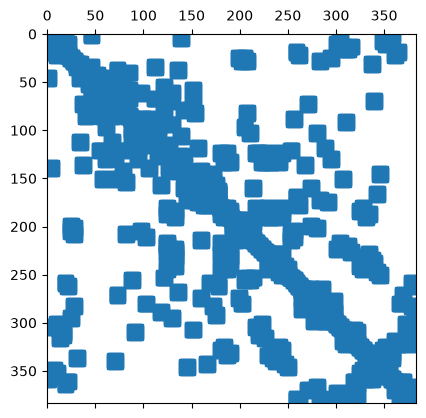

In [ ]:
import matplotlib.pyplot as plt 
plt.spy(A)

In [ ]:
b = P.assemble_RHS()

In [ ]:
P.solve()

/home/manuel/Documentos/Trefftz/problems/base2.py:288: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
  u_h = spsolve(A=self.A, b=self.b)


In [ ]:
P.u_h.reshape((-1,3))

array([[ 8.62930463e-01+2.12088008e-01j,  2.31135206e-01-7.08575461e-01j,
        -8.79317457e-01+3.49924218e-02j],
       [ 1.12084283e+00+2.73595560e-02j, -1.61627702e-01-1.86401074e-01j,
         2.05137268e-01-5.37469520e-02j],
       [ 1.10752918e+00+3.13565554e-02j,  1.16317043e-01-1.37535758e-01j,
        -7.97496393e-03-2.41874760e-01j],
       [ 8.39999534e-01+3.04191576e-01j, -6.56594258e-01+7.06523335e-01j,
         6.56573367e-01-3.81972374e-01j],
       [ 9.98183320e-01+3.02031346e-01j,  9.00109198e-02-7.26804933e-01j,
        -9.43342246e-01+1.34592864e-02j],
       [ 1.06862402e+00+1.38041202e-02j, -1.43477072e-01-2.14114960e-01j,
         1.88993675e-01-6.52310881e-02j],
       [ 1.11496745e+00+2.67158378e-02j,  1.30620966e-01-1.76098667e-01j,
        -1.20526188e-02-2.51429276e-01j],
       [ 8.15416758e-01+2.58137798e-01j, -7.36891357e-01+4.51934253e-01j,
         5.53538441e-01-3.88628303e-01j],
       [ 9.54264079e-01-2.26156163e-02j,  1.13093442e-01-2.35437716e-02j

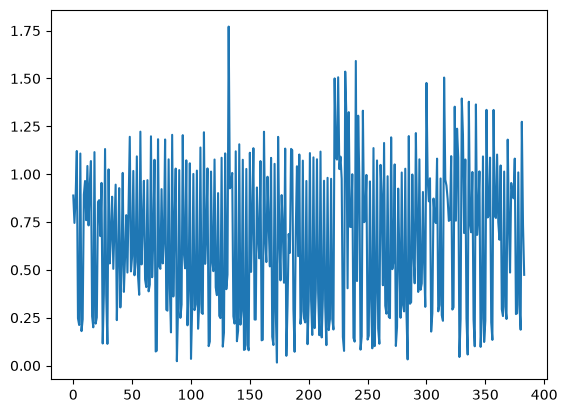

In [ ]:
import numpy as np
plt.plot(np.abs(P.u_h))

In [ ]:
from trefftz.dg.functions2 import TrefftzFunction

In [ ]:
u_h = TrefftzFunction(mesh=mesh, basis=basis)

In [ ]:
u_h.set(coefficients=P.u_h)

In [ ]:
import numpy as np
N = 100
x = np.linspace(-R, R, N)
y = np.linspace(0., H, N)
X, Y = np.meshgrid(x, y)
Z = u_h(X.ravel(), Y.ravel()).reshape(X.shape)

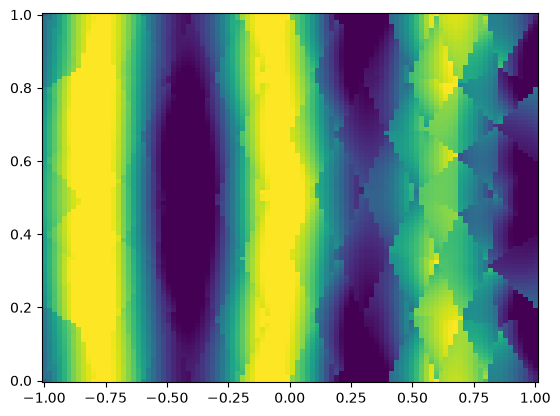

In [ ]:
import matplotlib.pyplot as plt 
plt.pcolormesh(X, Y, Z.real,vmin=-1, vmax=1)